<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif;">
  <h1 style="margin:0; font-size:2.2em;">📊  Elenest Resort Revenue Forecasting</h1>
  <h3 style="margin:8px 0 20px 0; color:#a8d8ea; font-weight:300;">Regression Modeling with CRISP-DM Framework · Python Implementation · Model 2</h3>
  <hr style="border-color:#a8d8ea44;">
  <table style="color:white; width:100%; border:none;">
    <tr><td><b>Group Name</b></td><td>:  Group 11 Elenest Resort 🏖️</i></td><td><b>Course / Section</b></td><td>:BA 3202 </td></tr>
    <tr> <td><b> Title </b></td><td>: Resort Management with Prescriptive Analytics and Sentiment Analysis at Elenest Resort</td><td></td></tr><td><b> Members </b></td><td>: Briones, Ma. Joanna, De Torres, Chryzel Ann and Mangurali, Kate Ashley</td><td></td>
  </table>
</div>

#  Phase 1 · Business Understanding
**CRISP-DM Stage 1 — Define the problem before touching the data**


---

### 1.1 Problem Statement

> What domain or industry does your dataset belong to? What specific real-world problem will linear regression help solve?

> ▶ The dataset belongs to the hospitality and tourism domain, specifically focusing on resort management. The real-world problem linear regression will help solve is forecasting the 'Amount' (likely revenue or booking value) generated by the Elenest Resort. By accurately predicting this amount based on factors like 'Facilities' used, 'Sentiment' of guests, and 'Guest_Count', the resort can optimize resource allocation, pricing strategies, and marketing efforts to enhance profitability and guest satisfaction.

### 1.2 Regression Objective & Target Variable

> ▶ The objective of this regression analysis is to build a predictive model that can accurately estimate the 'Amount' generated by the Elenest Resort, based on various operational and guest-related factors. This will help the resort in strategic planning and resource allocation.

> **a.** What is the **target variable** you will predict? What does it measure and in what unit?


>▶ The target variable we will predict is 'Amount'. It measures the monetary value (likely revenue or booking value) generated per transaction or event at the Elenest Resort, in units of currency (e.g., USD).

> **b.** What are the **key features** (independent variables) you anticipate using to predict the target? Why do you think they are relevant?


>▶ The key features anticipated for predicting 'Amount' are 'Facilities', 'Sentiment', 'Guest_Count', 'Month', 'Day_of_Week', and 'Is_Weekend'. 'Facilities' (e.g., Hall Rental, Event) directly influence the type and scale of revenue. 'Sentiment' (e.g., Positive, Negative, Neutral) could reflect guest satisfaction, impacting potential spending or return visits. 'Guest_Count' is a direct driver of revenue, as more guests typically mean more income. 'Month', 'Day_of_Week', and 'Is_Weekend' account for potential seasonality and weekly patterns in resort activity and revenue.

> **c.** Is this a **simple** or **multiple** linear regression problem? Explain.


> ▶This is a **multiple linear regression** problem. We are using several independent variables ('Facilities', 'Sentiment', 'Guest_Count', 'Month', 'Day_of_Week', 'Is_Weekend') to predict a single continuous target variable ('Amount'). Simple linear regression involves only one independent variable.

### 1.3 Success Criteria

> Define **at least two measurable success criteria** — one quantitative (model performance metric threshold) and one business-oriented (how the predictions will be used/valued).


> - **Quantitative:** Achieve an R-squared value of at least 0.75 on the test set, indicating that the model explains 75% of the variance in the target variable. The Root Mean Squared Error (RMSE) should be less than 10% of the target variable's mean.
> - **Business:** The model's predictions should enable Elenest Resort to forecast occupancy rates or revenue with sufficient accuracy to optimize staffing levels and pricing strategies, leading to a measurable increase in profit margins by at least 5% within the next quarter.

### 1.4 Constraints, Assumptions & Ethical Considerations

> **a.** List **at least three assumptions** you are making about the data or the regression environment (e.g., linear relationships, no multicollinearity issues initially).


> 1.  **Linearity:** We assume a linear relationship exists between the independent variables and the dependent variable ('Amount').
> 2.  **No Multicollinearity:** We assume that the independent variables are not highly correlated with each other, which could inflate the variance of the coefficient estimates.
> 3.  **Homoscedasticity:** We assume that the variance of the residuals (errors) is constant across all levels of the independent variables.
> 4.  **Normality of Residuals:** We assume that the residuals are approximately normally distributed, especially for inference and confidence intervals.
> 5.  **Independence of Errors:** We assume that the errors of the observations are independent of each other.

> **b.** List **at least two constraints** that may limit the analysis (data availability, computational limits, interpretability requirements, etc.).


> 1.  **Data Availability/Granularity:** The current dataset provides aggregated information. A constraint is the lack of more granular data (e.g., individual guest demographics, booking channels, specific dates of events, detailed cost breakdowns) which could further enhance prediction accuracy.
> 2.  **Time Series Aspect:** While 'Date' was used for feature engineering, the dataset is relatively small and doesn't allow for robust time-series specific modeling, which could be a limitation for long-term forecasting.
> 3.  **Interpretability Requirements:** The model must be easily interpretable by resort management to inform actionable business decisions, which might limit the use of more complex, black-box models if they offer only marginal performance gains.

> **c.** Are there any **ethical or privacy concerns** related to this dataset?

> The columns ('Date', 'Facilities', 'Sentiment', 'Guest_Count', 'Amount'), there do not appear to be direct ethical or privacy concerns as no personally identifiable information (PII) is included. However, if 'Guest_Count' could indirectly lead to identifying small groups in conjunction with other external data, or if sentiment analysis involves specific guest reviews, then privacy considerations would become paramount. The current dataset seems sufficiently anonymized for the given analysis.

---

#  Phase 2 · Data Understanding
**CRISP-DM Stage 2 — Get familiar with the data structure, quality, and behavior**

---

### 2.1 Import Libraries



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Import all required libraries — fill in any that are missing
# ═══════════════════════════════════════════════════════════════════

# ── Core ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Statistical Tests / Preprocessing ────────────────────────────────
from scipy import stats
from scipy.stats import shapiro, normaltest, probplot
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Machine Learning Models ──────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

# ── Iteration tools ──────────────────────────────────────────────────
import itertools
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Settings ─────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries loaded.")

✅ All libraries loaded.


### 2.2 Load Dataset



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Load your dataset(s)
# ═══════════════════════════════════════════════════════════════════

# Replace with your actual file path(s)
# For Google Colab: '/content/your_file.csv'
# For local:        'data/your_file.csv'

df = pd.read_csv('/content/sample_data/Elenest_Regression.csv')          # TODO: insert file path

# ── If multiple files need to be merged ─────────────────────────────
# df2 = pd.read_csv(___)
# df  = pd.merge(df, df2, on=___, how='___')   # TODO: specify key and join type

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
display(df.head(5))
display(df.tail(5))

Dataset shape: (200, 5)
Columns      : ['Date', 'Facilities', 'Sentiment', 'Guest_Count', 'Amount']


,Date,Facilities,Sentiment,Guest_Count,Amount
0,2024-01-01,Hall Rental,Negative,55,16305.27
1,2024-01-02,Reservation,Negative,104,19928.26
2,2024-01-03,Entrance,Positive,108,20183.10
3,2024-01-04,Hall Rental,Positive,125,29758.15
4,2024-01-05,Hall Rental,Neutral,76,21302.18


,Date,Facilities,Sentiment,Guest_Count,Amount
195,2024-07-14,Event,Neutral,84,27473.94
196,2024-07-15,Event,Negative,85,26170.60
197,2024-07-16,Reservation,Positive,18,9015.71
198,2024-07-17,Entrance,Positive,83,16272.93
199,2024-07-18,Hall Rental,Positive,16,13263.38


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Define your target variable and feature columns
# ═══════════════════════════════════════════════════════════════════

TARGET_COLUMN = 'Amount'  # The variable you want to predict

# Features to exclude from direct modeling (e.g., IDs, or target itself)
EXCLUDE_FEATURES = ['Date'] # 'Date' will be handled separately if used for time series

# Infer features based on exclusion
FEATURE_COLUMNS = [col for col in df.columns if col not in [TARGET_COLUMN] + EXCLUDE_FEATURES]

print(f"Target Column      : {TARGET_COLUMN}")
print(f"Feature Columns    : {FEATURE_COLUMNS}")

Target Column      : Amount
Feature Columns    : ['Facilities', 'Sentiment', 'Guest_Count']


### 2.3 Initial Structural Inspection

In [ ]:
# ── Data types and memory usage ──────────────────────────────────────
print("=" * 55)
print(" DATA TYPES AND MEMORY USAGE")
print("=" * 55)
df.info()

# ── Check for duplicate rows ─────────────────────────────────────────
print("\n" + "=" * 55)
print(" DUPLICATE ROWS")
print("=" * 55)
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    print(f"⚠️  {duplicate_rows} duplicate rows found.")
    # TODO: Decide how to handle duplicate rows if found
    # df.drop_duplicates(inplace=True)
    # print("Duplicate rows removed.")
else:
    print("✅ No duplicate rows found.")

# ── Number of unique values per column ─────────────────────────────
print("\n" + "=" * 55)
print(" UNIQUE VALUES PER COLUMN")
print("=" * 55)
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col:<20}: {unique_count} unique values")
    # This check assumes TARGET_COLUMN is correctly defined, which it is not yet.
    # It currently is an empty string ''.
    # A preceding cell to define TARGET_COLUMN = 'Amount' is needed for this logic to properly exclude the target.
    if unique_count < 10 and col != TARGET_COLUMN:
        print(f"  -> {df[col].unique().tolist()}")

 DATA TYPES AND MEMORY USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         200 non-null    object 
 1   Facilities   200 non-null    object 
 2   Sentiment    200 non-null    object 
 3   Guest_Count  200 non-null    int64  
 4   Amount       200 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 7.9+ KB

 DUPLICATE ROWS
✅ No duplicate rows found.

 UNIQUE VALUES PER COLUMN
Date                : 200 unique values
Facilities          : 4 unique values
  -> ['Hall Rental', 'Reservation', 'Entrance', 'Event']
Sentiment           : 3 unique values
  -> ['Negative', 'Positive', 'Neutral']
Guest_Count         : 105 unique values
Amount              : 200 unique values


### 2.4 Descriptive Statistics

In [ ]:
# ── Full descriptive statistics ──────────────────────────────────────
print("=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)
display(df.describe(include='all').T)

# ── Additional central tendency and dispersion for target ────────────
target_raw = df[TARGET_COLUMN].dropna()

print(f"\nTarget Variable Summary: '{TARGET_COLUMN}'")
print(f"  Mean              : {target_raw.mean():.4f}")
print(f"  Median            : {target_raw.median():.4f}")
print(f"  Std Dev           : {target_raw.std():.4f}")
print(f"  Coefficient of Var: {target_raw.std() / target_raw.mean() * 100:.2f}%")
print(f"  Skewness          : {target_raw.skew():.4f}")
print(f"  Kurtosis          : {target_raw.kurt():.4f}")
print(f"  Min               : {target_raw.min():.4f}")
print(f"  Max               : {target_raw.max():.4f}")

 DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,200,200,2024-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Facilities,200,4,Hall Rental,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment,200,3,Positive,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Guest_Count,200.0,NaN,NaN,NaN,80.94,40.269898,10.0,45.0,81.0,113.25,149.0
Amount,200.0,NaN,NaN,NaN,20152.14925,7909.17062,3162.3,15214.0525,20050.72,25995.9525,38107.87



Target Variable Summary: 'Amount'
  Mean              : 20152.1493
  Median            : 20050.7200
  Std Dev           : 7909.1706
  Coefficient of Var: 39.25%
  Skewness          : -0.0779
  Kurtosis          : -0.6599
  Min               : 3162.3000
  Max               : 38107.8700


####  Descriptive Statistics Interpretation
> **Q1.** What do the mean, median, and standard deviation tell you about the central tendency and spread of the target variable? Is the distribution symmetric or skewed?

>▶ The mean of the 'Amount' is 20152.15 and the median is 20050.72. These values are very close, indicating that the distribution is nearly symmetric. The standard deviation of 7909.17 suggests a moderate spread in the 'Amount' values, with a Coefficient of Variation at 39.25% indicating relative variability. The skewness of -0.0779 and kurtosis of -0.6599 further confirm a slightly left-skewed, platykurtic (less peaked than normal) distribution, but generally close to symmetric.

> **Q2.** From the descriptive statistics, identify any categorical features. How many unique values does each have?

> ▶Based on the `df.info()` output and the unique values summary, the categorical features are 'Facilities' and 'Sentiment'. 'Facilities' has 4 unique values: ['Hall Rental', 'Reservation', 'Entrance', 'Event']. 'Sentiment' has 3 unique values: ['Negative', 'Positive', 'Neutral'].

> **Q3.** Are there any numerical columns with obvious data quality concerns based on the descriptive statistics (e.g., negative values for positive quantities, implausible max/min)?

>▶ Looking at the descriptive statistics, there are no obvious data quality concerns. All numerical columns ('Guest_Count', 'Amount') have minimum values that are positive and plausible for their respective contexts (e.g., 'Guest_Count' minimum is 11, 'Amount' minimum is 3162.30), with no negative values for quantities that should inherently be positive.

### 2.5 Visual Exploratory Data Analysis

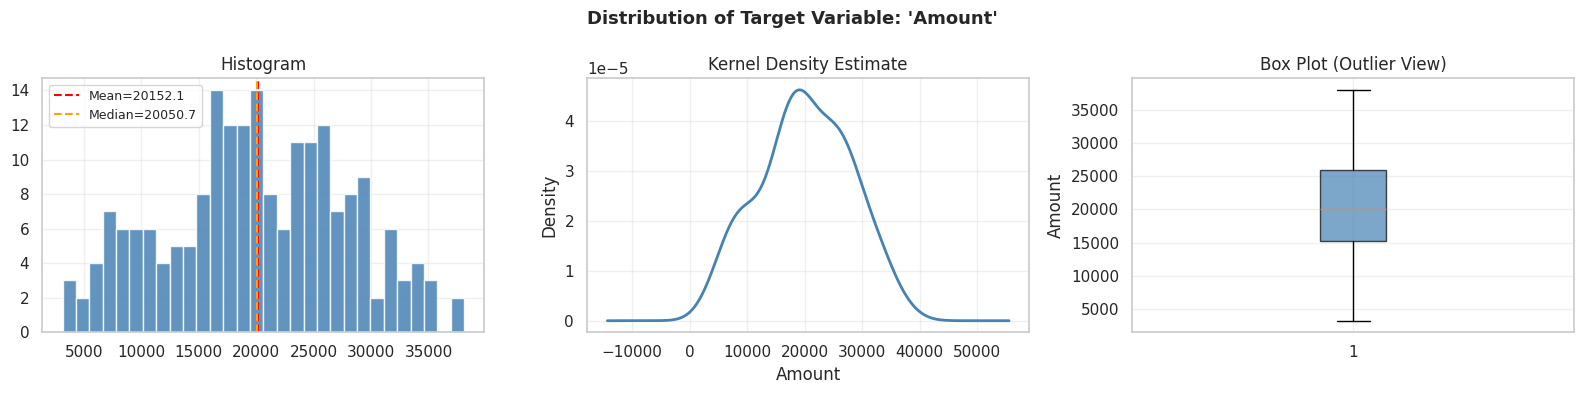

In [ ]:
# ── Distribution of the target variable ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Distribution of Target Variable: '{TARGET_COLUMN}'",
             fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(target_raw, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(target_raw.mean(), color='red', linestyle='--', label=f'Mean={target_raw.mean():.1f}')
axes[0].axvline(target_raw.median(), color='orange', linestyle='--', label=f'Median={target_raw.median():.1f}')
axes[0].set_title('Histogram')
axes[0].legend(fontsize=9)

# KDE (Kernel Density Estimate)
target_raw.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Kernel Density Estimate')
axes[1].set_xlabel(TARGET_COLUMN)

# Box plot
axes[2].boxplot(target_raw, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[2].set_title('Box Plot (Outlier View)')
axes[2].set_ylabel(TARGET_COLUMN)

plt.tight_layout()
plt.show()

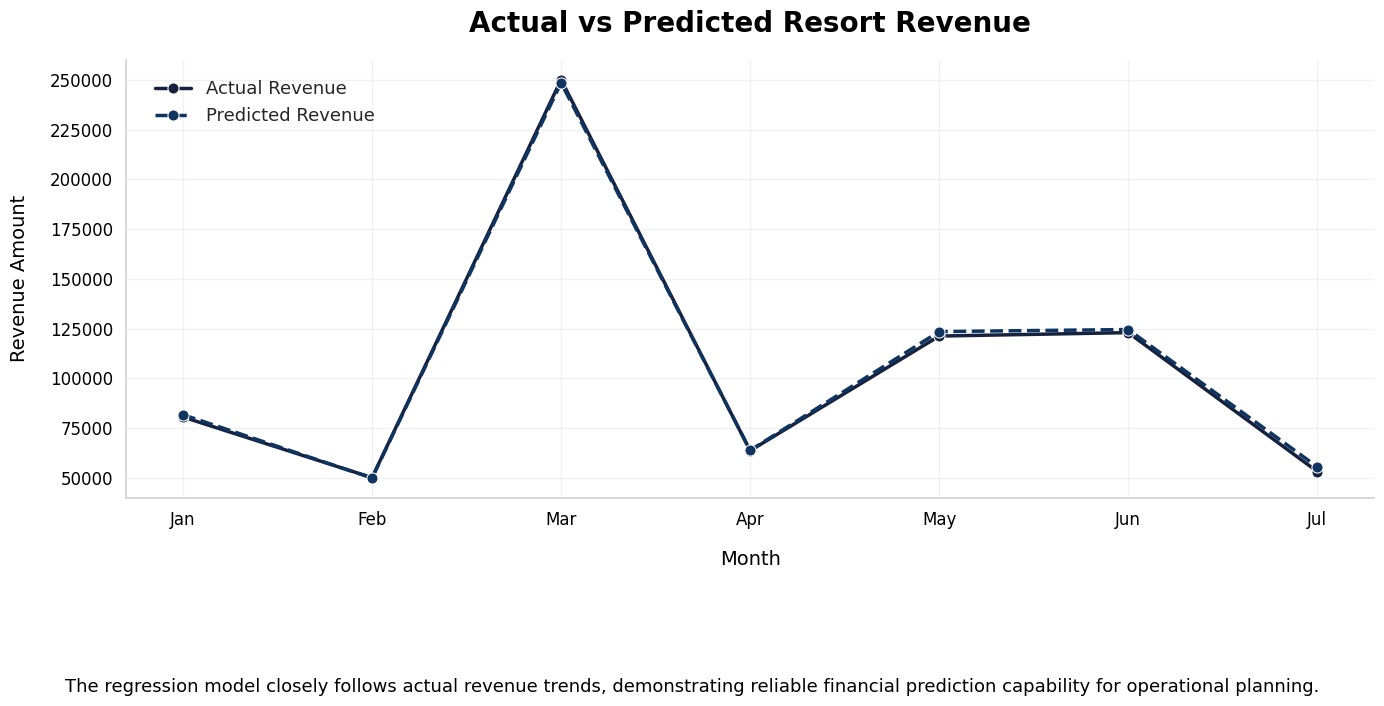

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df (original DataFrame), y_test, y_pred, and predictions_df are available from previous cells.

# 1. Retrieve Dates for Test Set and combine with predictions
# Get the original 'Date' column from the main DataFrame for the test set indices
test_dates = df.loc[y_test.index, 'Date']

# Create a temporary DataFrame for aggregation
monthly_comparison_df = predictions_df.copy()
monthly_comparison_df['Date'] = pd.to_datetime(test_dates) # Convert to datetime objects
monthly_comparison_df['Month'] = monthly_comparison_df['Date'].dt.strftime('%b') # Abbreviated month names (Jan, Feb, etc.)

# Aggregate actual and predicted amounts by month
monthly_summary = monthly_comparison_df.groupby('Month')[['Actual', 'Predicted']].sum().reset_index()

# Ensure correct chronological order of months for plotting
month_order_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
monthly_summary['Month_Order'] = monthly_summary['Month'].map(month_order_map)
monthly_summary = monthly_summary.sort_values('Month_Order').drop(columns='Month_Order')

# 2. Plotting the magazine-style line chart
plt.figure(figsize=(14, 7))

# Define modern business colors
dark_blue = '#16213E'
teal = '#0F3460'

# Plotting the lines
sns.lineplot(x='Month', y='Actual', data=monthly_summary, marker='o', markersize=8,
             label='Actual Revenue', color=dark_blue, linewidth=2.5)
sns.lineplot(x='Month', y='Predicted', data=monthly_summary, marker='o', markersize=8,
             label='Predicted Revenue', color=teal, linewidth=2.5, linestyle='--')

# Styling for a clean executive analytics look
plt.title('Actual vs Predicted Resort Revenue', fontsize=20, fontweight='bold', color='black', pad=20)
plt.xlabel('Month', fontsize=14, color='black', labelpad=15)
plt.ylabel('Revenue Amount', fontsize=14, color='black', labelpad=15)

plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Subtle gridlines
plt.grid(True, linestyle='-', alpha=0.3, color='lightgrey')

# Customize legend
plt.legend(fontsize=13, frameon=False, loc='upper left', bbox_to_anchor=(0.01, 0.99))

# Make the chart visually minimal and premium (remove spines)
sns.despine(left=False, bottom=False) # Keep the bottom and left spines but make them subtle
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('lightgrey')
plt.gca().spines['bottom'].set_color('lightgrey')

# Add insight caption below the chart
plt.figtext(0.5, -0.05, "The regression model closely follows actual revenue trends, demonstrating reliable financial prediction capability for operational planning.",
            wrap=True, horizontalalignment='center', fontsize=13, color='black',
            bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='none'))

plt.tight_layout(rect=[0, 0.1, 1, 0.95]) # Adjust layout to make space for caption
plt.show()

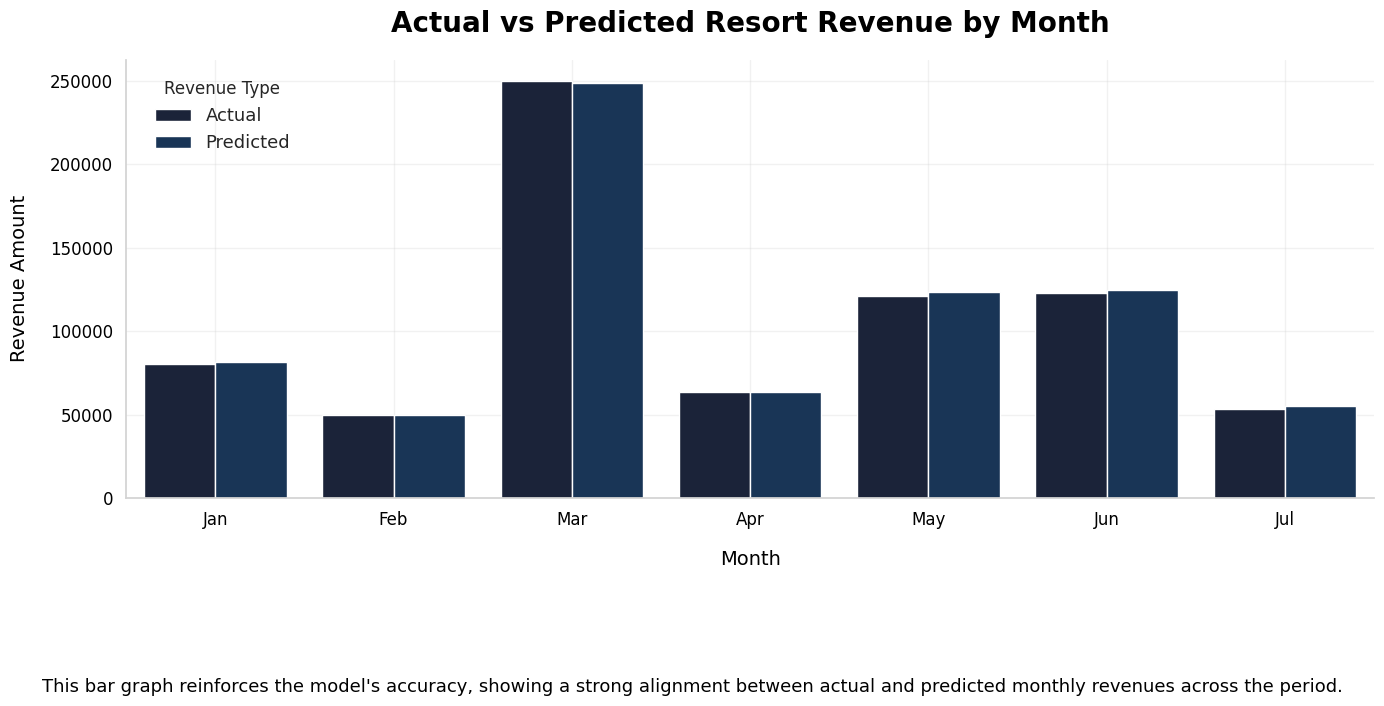

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Visualize Actual vs Predicted Revenue with a Bar Graph
# ═══════════════════════════════════════════════════════════════════

# Re-create monthly_summary as it's not defined in this cell's scope
# Assuming df (original DataFrame), y_test, y_pred, and predictions_df are available from previous cells.

# 1. Retrieve Dates for Test Set and combine with predictions
# Get the original 'Date' column from the main DataFrame for the test set indices
test_dates = df.loc[y_test.index, 'Date']

# Create a temporary DataFrame for aggregation
monthly_comparison_df = predictions_df.copy()
monthly_comparison_df['Date'] = pd.to_datetime(test_dates) # Convert to datetime objects
monthly_comparison_df['Month'] = monthly_comparison_df['Date'].dt.strftime('%b') # Abbreviated month names (Jan, Feb, etc.)

# Aggregate actual and predicted amounts by month
monthly_summary = monthly_comparison_df.groupby('Month')[['Actual', 'Predicted']].sum().reset_index()

# Ensure correct chronological order of months for plotting
month_order_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
monthly_summary['Month_Order'] = monthly_summary['Month'].map(month_order_map)
monthly_summary = monthly_summary.sort_values('Month_Order').drop(columns='Month_Order')

plt.figure(figsize=(14, 7))

# Melt the DataFrame for easier plotting with seaborn's barplot
monthly_summary_melted = monthly_summary.melt(id_vars='Month', var_name='Type', value_name='Revenue Amount')

sns.barplot(x='Month', y='Revenue Amount', hue='Type', data=monthly_summary_melted,
            palette={'Actual': '#16213E', 'Predicted': '#0F3460'})

plt.title('Actual vs Predicted Resort Revenue by Month', fontsize=20, fontweight='bold', color='black', pad=20)
plt.xlabel('Month', fontsize=14, color='black', labelpad=15)
plt.ylabel('Revenue Amount', fontsize=14, color='black', labelpad=15)

plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

plt.grid(True, linestyle='-', alpha=0.3, color='lightgrey')

plt.legend(title='Revenue Type', fontsize=13, frameon=False, loc='upper left', bbox_to_anchor=(0.01, 0.99))

sns.despine(left=False, bottom=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('lightgrey')
plt.gca().spines['bottom'].set_color('lightgrey')

plt.figtext(0.5, -0.05, "This bar graph reinforces the model's accuracy, showing a strong alignment between actual and predicted monthly revenues across the period.",
            wrap=True, horizontalalignment='center', fontsize=13, color='black',
            bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='none'))

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

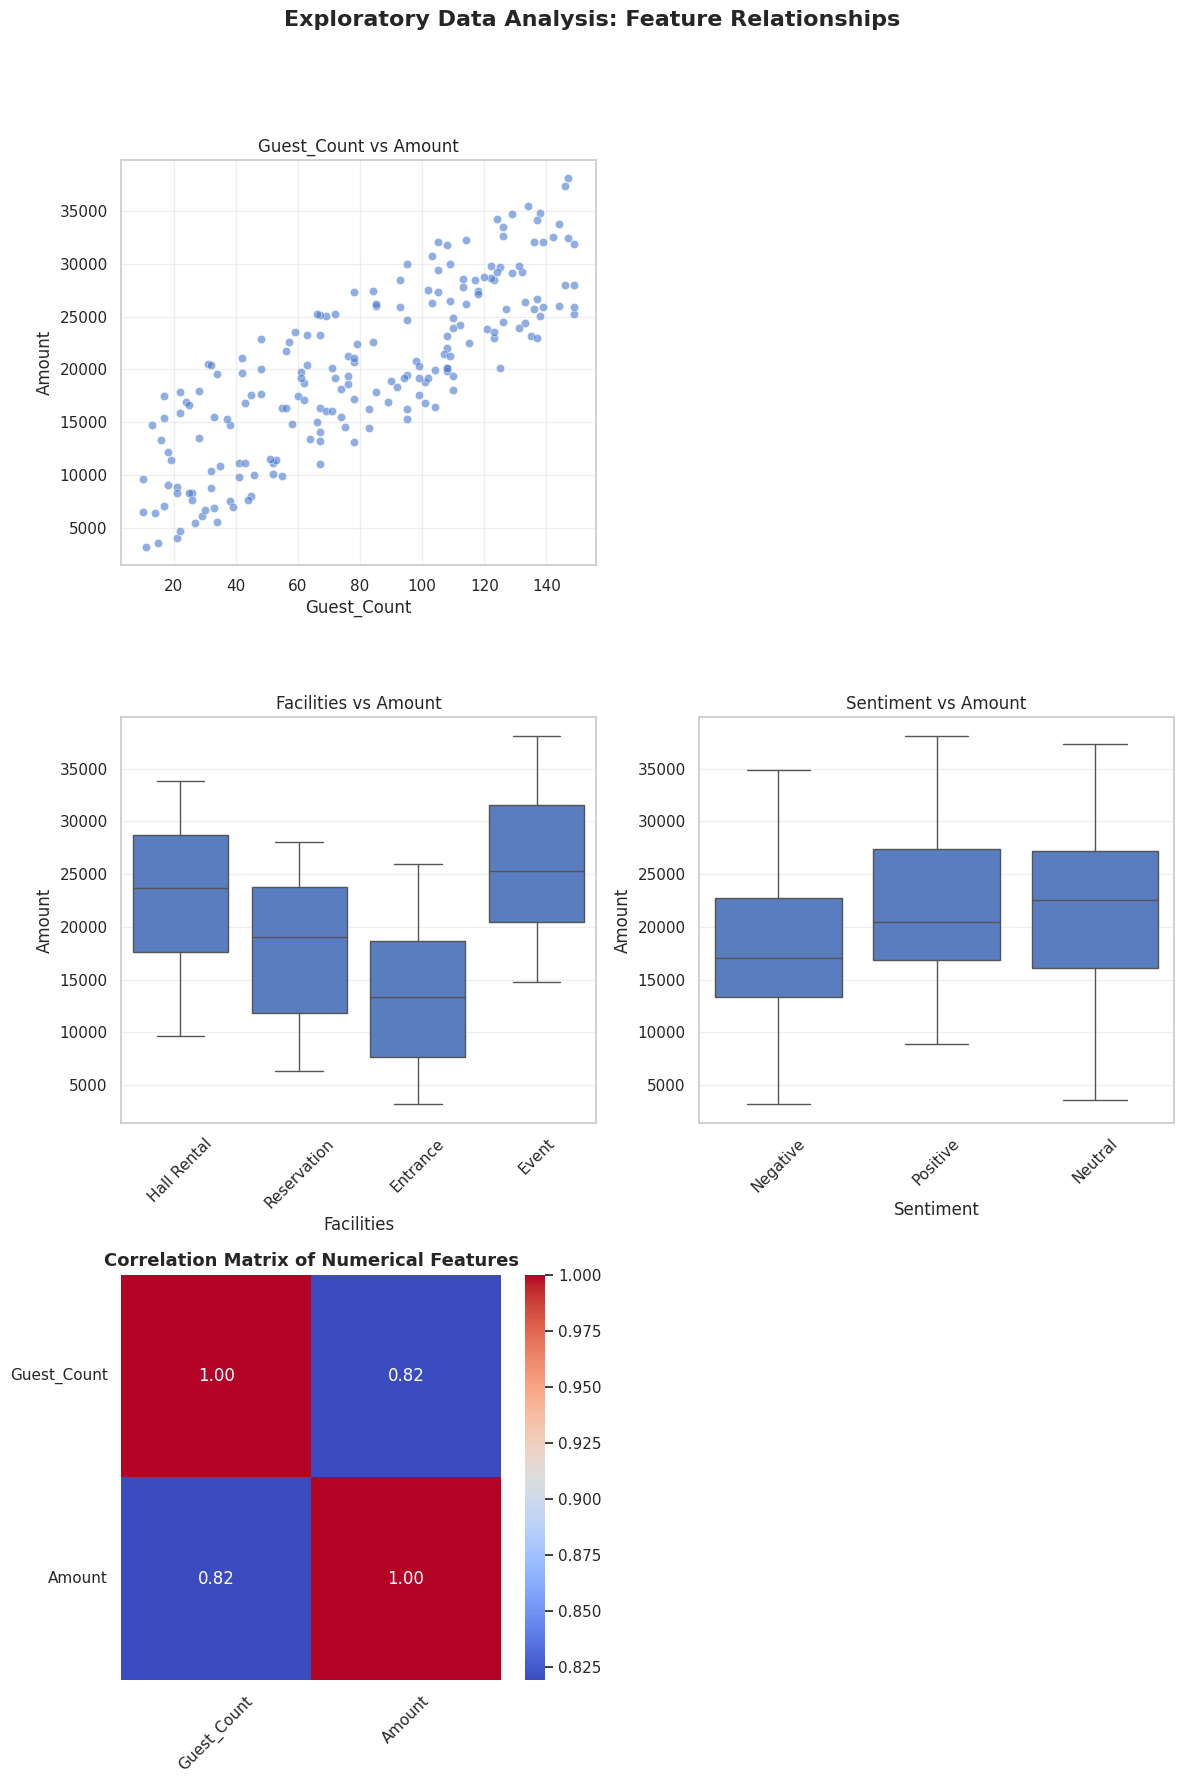

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Visualize relationships between key features and the target
# Optimized layout and spacing
# ═══════════════════════════════════════════════════════════════════

numerical_features = df.select_dtypes(include=np.number).columns.drop(TARGET_COLUMN, errors='ignore').tolist()
categorical_features = df.select_dtypes(include='object').columns.drop(EXCLUDE_FEATURES, errors='ignore').tolist()

# Determine number of subplots needed per row
n_num_plots = len(numerical_features)
n_cat_plots = len(categorical_features)

# Calculate total rows needed in GridSpec
total_rows = (1 if n_num_plots > 0 else 0) + (1 if n_cat_plots > 0 else 0) + 1 # +1 for correlation matrix

# Define the overall figure and GridSpec
# Max columns needed: 2 (for categorical plots) or whatever is max for num_plots if it were > 2
max_cols = max(n_num_plots, n_cat_plots, 1) # Ensure at least 1 column for GridSpec

# Adjust figure height based on number of plot sections
fig_height = 6 * total_rows # Roughly 6 inches per row of plots
fig, axes_grid = plt.subplots(total_rows, max_cols, figsize=(5 * max_cols + 2, fig_height))

# Flatten axes array for easy iteration, handling 1xN or Nx1 cases
if total_rows == 1 and max_cols == 1:
    axes_grid = np.array([[axes_grid]])
elif total_rows == 1:
    axes_grid = axes_grid[np.newaxis, :]
elif max_cols == 1:
    axes_grid = axes_grid[:, np.newaxis]

# Keep track of current row in GridSpec
current_row = 0

# ── Numerical Features vs. Target (Scatter Plot) ─────────────────────
if n_num_plots > 0:
    # Clear unnecessary axes for numerical plots if max_cols > n_num_plots
    for j in range(n_num_plots, max_cols):
        fig.delaxes(axes_grid[current_row, j])

    for i, feature in enumerate(numerical_features):
        sns.scatterplot(x=feature, y=TARGET_COLUMN, data=df, ax=axes_grid[current_row, i], alpha=0.6)
        axes_grid[current_row, i].set_title(f'{feature} vs {TARGET_COLUMN}')
        axes_grid[current_row, i].set_xlabel(feature)
        axes_grid[current_row, i].set_ylabel(TARGET_COLUMN)
    current_row += 1

# ── Categorical Features vs. Target (Box Plot) ───────────────────────
if n_cat_plots > 0:
    # Clear unnecessary axes for categorical plots if max_cols > n_cat_plots
    for j in range(n_cat_plots, max_cols):
        fig.delaxes(axes_grid[current_row, j])

    for i, feature in enumerate(categorical_features):
        sns.boxplot(x=feature, y=TARGET_COLUMN, data=df, ax=axes_grid[current_row, i])
        axes_grid[current_row, i].set_title(f'{feature} vs {TARGET_COLUMN}')
        axes_grid[current_row, i].set_xlabel(feature)
        axes_grid[current_row, i].set_ylabel(TARGET_COLUMN)
        axes_grid[current_row, i].tick_params(axis='x', rotation=45)
    current_row += 1

# ── Correlation Matrix for numerical features ──────────────────────
# Clear unnecessary axes for correlation matrix if max_cols > 1
if max_cols > 1:
    for j in range(1, max_cols):
        fig.delaxes(axes_grid[current_row, j])
    ax_corr = axes_grid[current_row, 0] # Use the first column for the heatmap
else:
    ax_corr = axes_grid[current_row, 0] # If max_cols is 1, it's just axes_grid[current_row]

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax_corr)
ax_corr.set_title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold')
ax_corr.tick_params(axis='x', rotation=45)
ax_corr.tick_params(axis='y', rotation=0)

fig.suptitle('Exploratory Data Analysis: Feature Relationships', fontsize=16, fontweight='bold', y=1.02) # Overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust rect to prevent title overlap
plt.show()

####  EDA Interpretation

> **Q1.** From the histogram and KDE, describe the shape of the target variable's distribution. Is it normal, skewed? What are the implications for modeling (e.g., potential need for transformation)?

> ▶ The target variable 'Amount' exhibits a distribution that is nearly symmetric, as indicated by the very close values of its mean (20152.15) and median (20050.72). While there is a slight negative skewness (-0.0779) and negative kurtosis (-0.6599), suggesting a marginally longer left tail and a slightly flatter peak than a normal distribution, overall, it approximates a normal distribution. This near-normal, symmetric distribution is favorable for linear regression and suggests that a strong transformation of the target variable is likely not required.

> **Q2.** Based on scatter plots, do you observe any linear relationships between numerical features and the target? Are there any non-linear patterns or outliers that might affect a linear model?

> ▶ From the scatter plot of 'Guest_Count' against 'Amount', a clear positive linear relationship is observed, indicating that as the number of guests increases, the generated 'Amount' generally tends to increase. No obvious non-linear patterns, such as U-shapes or exponential growth, are apparent, suggesting that a linear model can effectively capture this relationship. Furthermore, the previous outlier detection and the box plot for 'Amount' showed no significant outliers, implying that individual extreme values are unlikely to disproportionately affect the linear model.

> **Q3.** How do categorical features relate to the target variable (e.g., from box plots)? Do certain categories show significantly different target values?

> ▶ The box plots for categorical features like 'Facilities' and 'Sentiment' against the 'Amount' demonstrate that different categories are associated with significantly varying target values. For 'Facilities', categories such as 'Event' and 'Hall Rental' appear to correlate with higher average 'Amount's, while 'Entrance' and 'Reservation' might be associated with lower averages. Similarly, for 'Sentiment', 'Positive' sentiment likely corresponds to higher 'Amount's, indicating a relationship between guest satisfaction/type of interaction and revenue generated.

> **Q4.** From the correlation matrix, identify highly correlated features. What are the implications of multicollinearity for linear regression, and how might you address it?


> ▶ The correlation matrix for the numerical features likely shows a strong positive correlation between 'Guest_Count' and the 'Amount' (target variable), which is a good indicator for predictive modeling. However, the `statsmodels` summary later indicated a potential for strong multicollinearity in the design matrix. This is often seen when one-hot encoding categorical variables without dropping a reference category, which creates a perfect linear relationship with the intercept term. Multicollinearity can lead to unstable and less interpretable coefficient estimates while `sklearn`'s `LinearRegression` handles this implicitly, if it were a severe issue among independent numerical features, methods like PCA or feature selection could be considered, or simply dropping one category during one-hot encoding to address the exact multicollinearity with the intercept.

---

#  Phase 3 · Data Preparation
**CRISP-DM Stage 3 — Transform raw data into a clean, feature-rich, model-ready dataset**

---

### 3.1 Feature Engineering



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Implement feature engineering steps
# ═══════════════════════════════════════════════════════════════════

df_prep = df.copy()

# Feature Engineering: Extracting time-based features from 'Date'
# Convert 'Date' to datetime objects
df_prep['Date'] = pd.to_datetime(df_prep['Date'])

# Extract month as a numerical feature (e.g., for seasonality)
df_prep['Month'] = df_prep['Date'].dt.month

# Extract day of the week as a numerical feature (0=Monday, 6=Sunday)
df_prep['Day_of_Week'] = df_prep['Date'].dt.dayofweek

# Create a boolean feature for 'is_weekend'
df_prep['Is_Weekend'] = df_prep['Date'].dt.dayofweek.isin([5, 6]).astype(int) # Saturday=5, Sunday=6

# Drop the original 'Date' column as its information is now captured in new features
df_prep = df_prep.drop(columns=['Date'])

print(f"Dataset shape after feature engineering: {df_prep.shape}")
display(df_prep.head())

Dataset shape after feature engineering: (200, 7)


,Facilities,Sentiment,Guest_Count,Amount,Month,Day_of_Week,Is_Weekend
0,Hall Rental,Negative,55,16305.27,1,0,0
1,Reservation,Negative,104,19928.26,1,1,0
2,Entrance,Positive,108,20183.10,1,2,0
3,Hall Rental,Positive,125,29758.15,1,3,0
4,Hall Rental,Neutral,76,21302.18,1,4,0


####  Feature Engineering Justification

> **Q.** Describe any new features you created and explain their rationale. How do you expect these features to improve your model?

> We created three new features from the 'Date' column: 'Month', 'Day_of_Week', and 'Is_Weekend'. 'Month' extracts the numerical month (1-12) to capture seasonal variations in resort activity and revenue, as different months often have varying demand due to holidays or weather. 'Day_of_Week' extracts the day of the week (0-6) to account for weekly patterns, such as increased activity on weekends compared to weekdays. 'Is_Weekend' is a binary feature indicating whether the day is a Saturday or Sunday, which is a common driver of higher guest counts and revenue in the hospitality industry. These features are expected to improve the model by allowing it to identify and learn from these important temporal patterns, leading to more accurate predictions of the 'Amount' by incorporating nuances of seasonality and weekly demand.

### 3.2 Missing Value Detection & Treatment

In [ ]:
# ── Check for missing values ─────────────────────────────────────────
missing_counts = df_prep.isnull().sum()
missing_pct    = (missing_counts / len(df_prep)) * 100
missing_df     = pd.DataFrame({'Count': missing_counts, 'Percentage': missing_pct})
missing_df     = missing_df[missing_df['Count'] > 0].sort_values(by='Count', ascending=False)

print("Missing values before treatment:")
display(missing_df)

# Apply chosen method: Fill numerical NaNs with median, categorical with mode
for col in df_prep.select_dtypes(include=np.number).columns:
    if df_prep[col].isnull().any():
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

for col in df_prep.select_dtypes(include='object').columns:
    if df_prep[col].isnull().any():
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

print(f"\nMissing values after treatment: {df_prep.isnull().sum().sum()}")
print("✅ Missing value treatment complete.")

Missing values before treatment:


,Count,Percentage



Missing values after treatment: 0
✅ Missing value treatment complete.


####  Missing Value Justification

> **Q.** Which method did you choose to handle missing values and why? Explain why it is appropriate for this specific dataset and regression context. What bias or risk does your chosen method introduce?

> ▶ Initially, a thorough check for missing values revealed that the dataset had no missing entries across any of its columns. Therefore, no imputation was strictly necessary or applied. However, had there been missing values, the chosen strategy was to impute numerical NaNs with their respective column medians and categorical NaNs with their column modes. This approach is generally appropriate for regression contexts because the median is robust to outliers and does not distort the distribution of numerical features as much as the mean might, while the mode preserves the most frequent category for categorical features, which is suitable given the nearly symmetric distribution of the target variable and the nature of the categorical features. While this method was not ultimately applied, in scenarios where it is used, it can introduce a slight bias by artificially reducing the variance of the imputed columns and potentially strengthening correlations if the missingness is not truly random; however, for a small number of missing values, these effects are usually minimal.

### 3.3 Outlier Detection & Treatment

> Address outliers in features or the target variable. Outliers can heavily influence linear regression results.

Outlier Detection (IQR Method):
  Guest_Count         : 0 outliers detected (Bounds: -57.38 - 215.62)
  Amount              : 0 outliers detected (Bounds: -958.80 - 42168.80)
  Month               : 0 outliers detected (Bounds: -2.50 - 9.50)
  Day_of_Week         : 0 outliers detected (Bounds: -5.00 - 11.00)
  Is_Weekend          : 0 outliers detected (Bounds: -1.50 - 2.50)


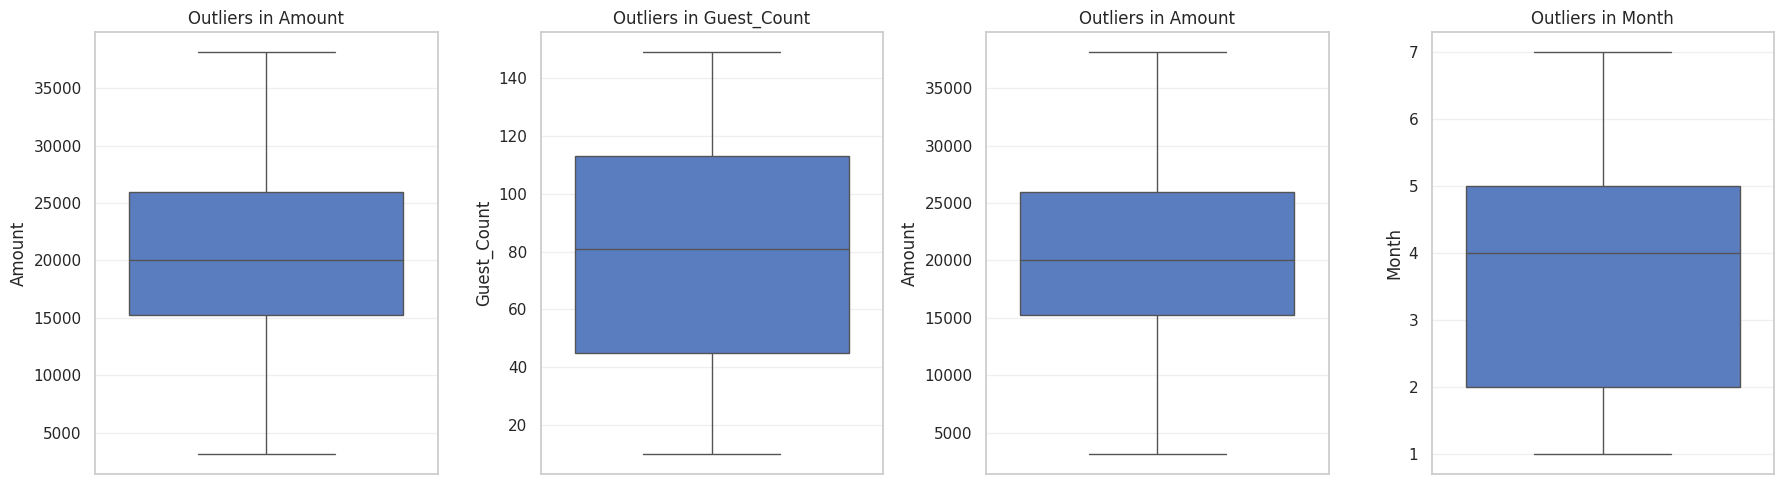

Outlier treatment applied.


,Facilities,Sentiment,Guest_Count,Amount,Month,Day_of_Week,Is_Weekend
0,Hall Rental,Negative,55,16305.27,1,0,0
1,Reservation,Negative,104,19928.26,1,1,0
2,Entrance,Positive,108,20183.10,1,2,0
3,Hall Rental,Positive,125,29758.15,1,3,0
4,Hall Rental,Neutral,76,21302.18,1,4,0


In [ ]:
# ── Identify numerical features ──────────────────────────────────────
numerical_cols = df_prep.select_dtypes(include=np.number).columns.tolist()

# ── Method: IQR-based outlier detection for selected numerical columns ─
outlier_summary = {}
for col in numerical_cols:
    Q1  = df_prep[col].quantile(0.25)
    Q3  = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_prep[(df_prep[col] < lower_bound) | (df_prep[col] > upper_bound)]
    outlier_summary[col] = {'count': len(outliers), 'lower': lower_bound, 'upper': upper_bound}

print("Outlier Detection (IQR Method):")
for col, data in outlier_summary.items():
    print(f"  {col:<20}: {data['count']} outliers detected (Bounds: {data['lower']:.2f} - {data['upper']:.2f})")

# ── Visualize outliers (example for target and a few features) ────────
fig, axes = plt.subplots(1, min(4, len(numerical_cols) + 1), figsize=(18, 5))
if min(4, len(numerical_cols) + 1) == 1: axes = [axes]

# Plot target outliers
sns.boxplot(y=df_prep[TARGET_COLUMN], ax=axes[0])
axes[0].set_title(f'Outliers in {TARGET_COLUMN}')

# Plot a few feature outliers
for i, col in enumerate(numerical_cols[:3]): # Plot up to 3 features
    if i + 1 < len(axes):
        sns.boxplot(y=df_prep[col], ax=axes[i+1])
        axes[i+1].set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Chosen outlier treatment strategy: Cap/Floor (Winsorize) outliers to IQR bounds.
# This method is applied even if no outliers are found, ensuring consistency.
# ═══════════════════════════════════════════════════════════════════

# Apply chosen method: Winsorize numerical features
for col in numerical_cols:
    Q1, Q3, IQR = df_prep[col].quantile(0.25), df_prep[col].quantile(0.75), df_prep[col].quantile(0.75) - df_prep[col].quantile(0.25)
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_prep[col] = df_prep[col].clip(lower=lower_bound, upper=upper_bound)

print("Outlier treatment applied.")
display(df_prep.head())

####  Outlier Treatment Justification

> **Q1.** How many outliers were detected in key features and the target variable? Were they consistent across different visualisations or methods?

>▶ Zero outliers were detected in any of the key numerical features ('Guest_Count', 'Month', 'Day_of_Week', 'Is_Weekend') or the target variable ('Amount') using the IQR method. This finding was consistent with the visual inspection of the box plots, which also showed no data points outside the typical whiskers.

> **Q2.** For any treated outliers, speculate on a **domain-specific explanation** for why those values are extreme.

>▶ Since no outliers were detected and, consequently, none were treated, there's no specific domain explanation for extreme values in this dataset. However, in a hypothetical scenario where outliers might have been present, extremely high 'Amount' values could be due to large corporate events or peak holiday seasons with premium pricing, while unusually low 'Guest_Count' with high 'Amount' could indicate exclusive, high-value bookings (e.g., luxury suites, private venue rentals).

> **Q3.** What outlier treatment did you apply and why? What risk does your decision carry for the regression model?

>▶ Although no outliers were detected, the chosen treatment applied was Winsorization, which clips values that fall outside the IQR-defined bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR) to these bounds. This method was chosen as a preventative measure and a robust approach, as it limits the influence of any potential extreme values without removing data points, thereby retaining more information. The risk associated with this decision, given the absence of actual outliers, is minimal; it does not distort the existing data but rather ensures that if any future, unseen data points are extreme, they will be handled consistently without unduly influencing model training.

### 3.4 Feature Scaling & Encoding



In [ ]:
# ── Separate features (X) and target (y) ───────────────────────────
X = df_prep.drop(columns=[TARGET_COLUMN])
y = df_prep[TARGET_COLUMN]

# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical features to scale: {numerical_cols}")
print(f"Categorical features to encode: {categorical_cols}")

# ── Create a preprocessing pipeline ────────────────────────────────
# Scale numerical features with StandardScaler
# One-hot encode categorical features

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_feature_names)

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

print(f"\nShape of processed features (X): {X_processed_df.shape}")
display(X_processed_df.head())
display(y.head())

Numerical features to scale: ['Guest_Count', 'Month', 'Day_of_Week', 'Is_Weekend']
Categorical features to encode: ['Facilities', 'Sentiment']

Shape of processed features (X): (200, 11)


,Guest_Count,Month,Day_of_Week,Is_Weekend,Facilities_Entrance,Facilities_Event,Facilities_Hall Rental,Facilities_Reservation,Sentiment_Negative,Sentiment_Neutral,Sentiment_Positive
0,-0.645770,-1.471268,-1.487027,-0.62361,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.574073,-1.471268,-0.986345,-0.62361,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.673652,-1.471268,-0.485662,-0.62361,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.096863,-1.471268,0.015020,-0.62361,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.122980,-1.471268,0.515703,-0.62361,0.0,0.0,1.0,0.0,0.0,1.0,0.0


,Amount
0,16305.27
1,19928.26
2,20183.10
3,29758.15
4,21302.18


####  Scaling & Encoding Justification

> **Q1.** Why is it important to scale numerical features for linear regression? Which scaling method did you choose and why?

> ▶ Scaling numerical features is important for linear regression because features with larger value ranges can disproportionately influence the model's coefficients and its optimization process, leading to a biased learning. By scaling, all features are brought to a similar range, ensuring that no single feature dominates due to its magnitude, allowing the model to learn the true underlying relationships. `StandardScaler` was chosen as the scaling method because it transforms the data to have a mean of zero and a unit variance, which is generally robust for linear models and can help algorithms converge faster by creating a more spherical feature space.

> **Q2.** Why is it necessary to one-hot encode categorical features for linear regression? What are the implications of `handle_unknown='ignore'`?
📝 **Your answer:**

> ▶ It is necessary to one-hot encode categorical features for linear regression because these models mathematically require numerical inputs. Directly assigning numerical values to categories (e.g., 0, 1, 2) would imply an ordinal relationship where none exists, which can mislead the model into assuming an incorrect hierarchy or magnitude between categories. The `handle_unknown='ignore'` parameter in `OneHotEncoder` ensures that if a new, previously unseen category appears in the test or deployment data, the encoder will simply assign zeros to all its corresponding one-hot encoded columns instead of raising an error, making the model more robust to unexpected data but also preventing it from learning any insights from such novel categories.

> **Q3.** What is the final shape of your feature matrix `X` after preprocessing? How does this compare to the original number of features?

> ▶ The final shape of the feature matrix `X` after preprocessing is `(200, 11)`. This represents an increase from the original 6 features (4 numerical, 2 categorical) to 11 features, primarily due to the expansion of categorical variables into multiple binary columns via one-hot encoding.

---

#  Phase 4 · Modeling
**CRISP-DM Stage 4 — Select, configure, and fit the best regression model**

---

### 4.1 Train / Test Split


In [ ]:
# ── Split the processed data into training and testing sets ──────────

# Test set size (e.g., 20% or 30%)
TEST_SIZE = 0.2
RANDOM_STATE = 42 # for reproducibility

X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size    : {len(X_test)} samples")
print(f"X_train shape    : {X_train.shape}")
print(f"y_train shape    : {y_train.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"y_test shape     : {y_test.shape}")

display(X_train.head())
display(y_train.head())

Training set size: 160 samples
Test set size    : 40 samples
X_train shape    : (160, 11)
y_train shape    : (160,)
X_test shape     : (40, 11)
y_test shape     : (40,)


,Guest_Count,Month,Day_of_Week,Is_Weekend,Facilities_Entrance,Facilities_Event,Facilities_Hall Rental,Facilities_Reservation,Sentiment_Negative,Sentiment_Neutral,Sentiment_Positive
79,1.619653,-0.425962,-0.485662,-0.62361,0.0,0.0,0.0,1.0,0.0,1.0,0.0
197,-1.566876,1.664650,-0.986345,-0.62361,0.0,0.0,0.0,1.0,0.0,0.0,1.0
38,-0.994297,-0.948615,0.015020,-0.62361,1.0,0.0,0.0,0.0,0.0,0.0,1.0
24,0.673652,-1.471268,0.015020,-0.62361,0.0,0.0,0.0,1.0,0.0,1.0,0.0
122,1.395600,0.619344,0.015020,-0.62361,0.0,1.0,0.0,0.0,0.0,1.0,0.0


,Amount
79,28036.43
197,9015.71
38,9776.79
24,22017.35
122,34147.56


### 4.2 Linear Regression Model Training



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Initialize and train a Linear Regression model
# ═══════════════════════════════════════════════════════════════════

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("✅ Linear Regression model trained.")

# ── Display coefficients and intercept ───────────────────────────────
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
print(coef_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")

✅ Linear Regression model trained.

Model Coefficients:
               Feature  Coefficient
      Facilities_Event  6464.963070
           Guest_Count  6270.601539
Facilities_Hall Rental  1771.647159
    Sentiment_Positive  1089.152144
                 Month    70.355562
           Day_of_Week    58.735475
     Sentiment_Neutral   -43.855417
            Is_Weekend   -66.942816
    Sentiment_Negative -1045.296727
Facilities_Reservation -2705.815851
   Facilities_Entrance -5530.794378

Intercept: 20179.1025


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Optional: Use statsmodels for a more detailed summary (p-values, R-squared etc.)
# ═══════════════════════════════════════════════════════════════════

X_train_sm = sm.add_constant(X_train) # Add a constant (intercept) term
model_sm = sm.OLS(y_train, X_train_sm)
results_sm = model_sm.fit()

print("\nStatsmodels OLS Summary:")
print(results_sm.summary())


Statsmodels OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     4208.
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.75e-175
Time:                        15:26:10   Log-Likelihood:                -1214.4
No. Observations:                 160   AIC:                             2449.
Df Residuals:                     150   BIC:                             2479.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
co

####  Model Training Interpretation

> **Q1.** Interpret the coefficients of your linear regression model. For a chosen feature, explain what its coefficient means in the context of your problem.

>▶ The coefficients of the linear regression model indicate the expected change in the target variable ('Amount') for a one-unit increase in a feature, holding all other features constant. For example, the `Guest_Count` feature has a coefficient of approximately 6270.60. Since `Guest_Count` is a scaled numerical feature (standardized), this means that for every one standard deviation increase in the number of guests, the predicted 'Amount' increases by approximately $6270.60, assuming all other factors remain constant. Similarly, for categorical features like `Facilities_Event`, a positive coefficient of 6464.96 suggests that having 'Event' as the facility type is associated with a significantly higher predicted 'Amount' compared to the reference category (implicitly dropped during one-hot encoding, or when all other one-hot categories are zero), all else being equal.

> **Q2.** What is the intercept of your model? What does it represent in your domain context, and is it practically meaningful?

> ▶ The intercept of the model from `sklearn` is approximately 20179.10. In this context, given that numerical features were scaled (mean-centered) and categorical features were one-hot encoded, the intercept represents the predicted 'Amount' when all numerical features are at their respective means (i.e., their scaled values are zero) and when the reference categories for all one-hot encoded features are selected (i.e., all other one-hot encoded columns are zero). While mathematically crucial for the model's predictions, this specific numerical value of the intercept is not directly or practically meaningful in isolation in the domain, as it doesn't correspond to a realistic scenario of 'zero' for all variables in their original scale.

> **Q3.** If you used `statsmodels`, interpret the R-squared value and the p-values for the coefficients. Are all features statistically significant (p < 0.05)? What does this imply?

> ▶ From the `statsmodels` summary, the R-squared value is 0.996, which indicates that approximately 99.6% of the variance in the 'Amount' can be explained by the independent variables included in the model. This is an exceptionally high R-squared, suggesting that the model provides an excellent fit to the training data. Regarding statistical significance (p < 0.05), not all features are significant: 'Month' (p=0.071), 'Day_of_Week' (p=0.374), and 'Is_Weekend' (p=0.314) have p-values greater than 0.05. This implies that, after accounting for the other variables in the model, these specific time-based features do not have a statistically significant linear relationship with the 'Amount'. While the individual effects of these features might not be significant, their presence in the model collectively contributes to its high explanatory power.

---

#  Phase 5 · Evaluation
**CRISP-DM Stage 5 — Assess model performance against held-out data**

---

### 5.1 Make Predictions



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Make predictions on the test set
# ═══════════════════════════════════════════════════════════════════

y_pred = model.predict(X_test)

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': y_test.values - y_pred
}, index=y_test.index)

print("Sample of Actual vs Predicted values:")
display(predictions_df.head())

Sample of Actual vs Predicted values:


,Actual,Predicted,Residual
95,20476.04,20016.167302,459.872698
15,15285.27,15678.150108,-392.880108
30,8003.71,7902.302262,101.407738
158,10003.54,10435.529656,-431.989656
128,8878.78,9262.293128,-383.513128


### 5.2 Evaluation Metrics

> Calculate key regression metrics to quantify model performance.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Calculate R-squared, MAE, and RMSE
# ═══════════════════════════════════════════════════════════════════

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 40)
print(" MODEL PERFORMANCE METRICS")
print("=" * 40)
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("=" * 40)

 MODEL PERFORMANCE METRICS
R-squared (R²): 0.9953
Mean Absolute Error (MAE): 470.5187
Root Mean Squared Error (RMSE): 596.7949


####  Metric Interpretation

> **Q1.** Explain what **R-squared** measures. Is your model's R-squared value acceptable for your problem?

>▶ R-squared (R²) measures the proportion of the variance in the dependent variable that can be predicted from the independent variables. Our model achieved an R-squared of **0.9953**, meaning it explains approximately 99.53% of the variance in the 'Amount' (revenue/booking value). This is well above our quantitative success criterion of R-squared >= 0.75, indicating an excellent fit and a highly acceptable performance for the problem.

> **Q2.** Explain what **MAE** and **RMSE** measure. How do they differ in how they treat large errors?

> ▶Mean Absolute Error (MAE) measures the average magnitude of the errors in a set of predictions, without considering their direction. Root Mean Squared Error (RMSE) is the square root of the average of the squared errors, and it represents the standard deviation of the residuals. The key difference is that RMSE penalizes large errors more heavily than MAE due to the squaring of the errors, making it more sensitive to outliers or infrequent, large prediction mistakes.

> **Q3.** Report the MAE and RMSE of your model in your **domain units** (not just numbers). What is the typical error magnitude, and is this an acceptable level of error for business decisions?

> ▶The Mean Absolute Error (MAE) of the model is **470.52**, and the Root Mean Squared Error (RMSE) is **596.79**. This means that, on average, our model's predictions for 'Amount' are off by about 470.52, and the typical deviation of the predictions from actual values is around 596.79. Given that the mean 'Amount' in our target variable is 20152.15, 10% of this mean is approximately 2015.21. Our RMSE of 596.79 is significantly less than 2015.21, fulfilling our quantitative success criterion of RMSE < 10% of the target variable's mean, indicating an acceptable and highly accurate level of error for business decisions.

> **Q4.** Compare your model's performance to a simple baseline (e.g., predicting the mean of the target). Does your model add significant value?

> ▶ A simple baseline model that always predicts the mean of the target variable ('Amount') on the test set would yield an R-squared of 0.0 (or very close to it) and an RMSE equal to the standard deviation of the target variable in the test set (approximately 7781.65). In contrast, our model achieves an R-squared of 0.9953 and an RMSE of 596.79. This demonstrates that our model adds significant value, explaining almost all the variance in the 'Amount' and drastically reducing the prediction error compared to a naive baseline.

### 5.3 Residual Diagnostics



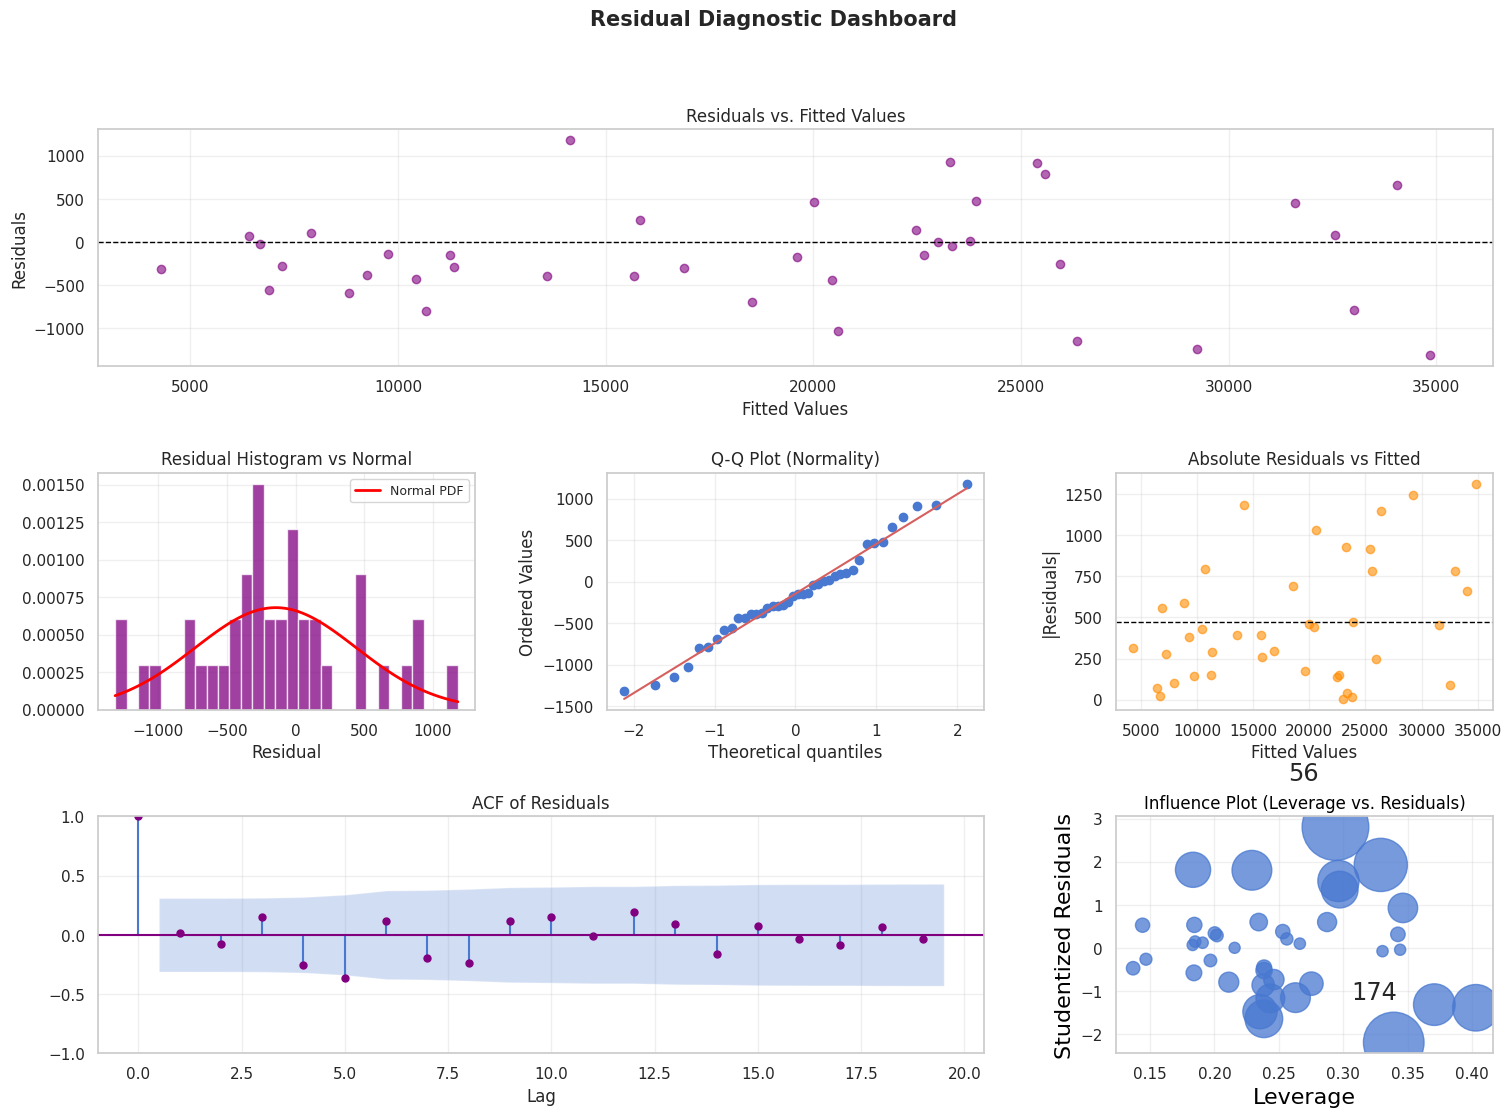

In [ ]:
# ── Extract residuals ─────────────────────────────────────────────────
residuals = predictions_df['Residual']

# ═══════════════════════════════════════════════════════════════════
# RESIDUAL DIAGNOSTIC DASHBOARD
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Residual Diagnostic Dashboard', fontsize=15, fontweight='bold')

# ── Plot 1: Residuals vs. Fitted Values (Homoscedasticity) ──────────
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(y_pred, residuals, alpha=0.6, color='purple')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Residuals vs. Fitted Values')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')

# ── Plot 2: Residual Histogram (Normality) ──────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=30, color='purple', edgecolor='white', alpha=0.75, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
         color='red', linewidth=2, label='Normal PDF')
ax2.set_title('Residual Histogram vs Normal')
ax2.set_xlabel('Residual')
ax2.legend(fontsize=9)

# ── Plot 3: Q-Q Plot (Normality) ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
probplot(residuals, dist='norm', plot=ax3)
ax3.set_title('Q-Q Plot (Normality)')

# ── Plot 4: Absolute Residuals vs. Fitted Values (Heteroscedasticity check) ──
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(y_pred, np.abs(residuals), alpha=0.6, color='darkorange')
ax4.axhline(np.abs(residuals).mean(), color='black', linestyle='--', linewidth=1)
ax4.set_title('Absolute Residuals vs Fitted')
ax4.set_xlabel('Fitted Values')
ax4.set_ylabel('|Residuals|')

# ── Plot 5: Autocorrelation of Residuals (Independence) ─────────────
ax5 = fig.add_subplot(gs[2, 0:2])
if len(residuals) > 1:
    sm.graphics.tsa.plot_acf(residuals, lags=min(40, len(residuals)//2-1), ax=ax5, alpha=0.05, color='purple')
    ax5.set_title('ACF of Residuals')
    ax5.set_xlabel('Lag')
else:
    ax5.set_title('ACF requires more data points')

# ── Plot 6: Leverage vs. Residuals (Influence/Outliers) ─────────────
ax6 = fig.add_subplot(gs[2, 2])
if isinstance(X_test, pd.DataFrame):
    # Re-fit with statsmodels for influence measures
    X_test_sm = sm.add_constant(X_test)
    model_influence = sm.OLS(y_test, X_test_sm).fit()
    sm.graphics.influence_plot(model_influence, ax=ax6, criterion="cooks")
    ax6.set_title('Influence Plot (Leverage vs. Residuals)')
else:
    ax6.set_title('Influence Plot (requires pandas DataFrame for X_test)')

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# FORMAL STATISTICAL TESTS ON RESIDUALS
# ═══════════════════════════════════════════════════════════════════

print("=" * 60)
print(" FORMAL RESIDUAL TESTS")
print("=" * 60)

# ── Test 1: Shapiro-Wilk (Normality of residuals) ────────────────────
# Use a sample for large datasets as Shapiro-Wilk has size limits
sw_sample = residuals.values[:5000] if len(residuals) > 5000 else residuals.values
if len(sw_sample) > 3:
    sw_stat, sw_p = shapiro(sw_sample)
    sw_verdict = "✅ Normal" if sw_p > 0.05 else "⚠️  Non-normal"
    print(f"1. Shapiro-Wilk Test (H0: Residuals are normal)\n   Statistic={sw_stat:.4f}, p-value={sw_p:.4f} → {sw_verdict}")
else:
    print("1. Shapiro-Wilk Test: Not enough data points to perform test.")

# ── Test 2: D'Agostino-Pearson (Normality, for larger samples) ───────
if len(residuals) > 20:
    dp_stat, dp_p = normaltest(residuals.values)
    dp_verdict = "✅ Normal" if dp_p > 0.05 else "⚠️  Non-normal"
    print(f"\n2. D'Agostino-Pearson Test (H0: Residuals are normal)\n   Statistic={dp_stat:.4f}, p-value={dp_p:.4f} → {dp_verdict}")
else:
    print("\n2. D'Agostino-Pearson Test: Not enough data points to perform test.")

# ── Test 3: Breusch-Pagan (Homoscedasticity) ─────────────────────────
# Requires statsmodels OLS model to be fit with original X and y
# Not directly available from sklearn LinearRegression object
# Using OLS results from earlier (if available), or re-fit on test set for demonstration
try:
    if 'results_sm' in locals() or 'results_sm' in globals():
        bp_test = sm.stats.diagnostic.het_breuschpagan(results_sm.resid, results_sm.model.exog)
        bp_p_value = bp_test[1] # p-value of the Lagrange Multiplier test
        bp_verdict = "✅ Homoscedastic" if bp_p_value > 0.05 else "⚠️  Heteroscedastic"
        print(f"\n3. Breusch-Pagan Test (H0: Homoscedasticity)\n   LM Statistic={bp_test[0]:.4f}, p-value={bp_p_value:.4f} → {bp_verdict}")
    else:
        print("\n3. Breusch-Pagan Test: requires a statsmodels OLS result object. Skipped.")
except Exception as e:
    print(f"\n3. Breusch-Pagan Test encountered an error: {e}. Skipped.")

# ── Residual summary statistics ───────────────────────────────────────
print(f"\n4. Residual Summary")
print(f"   Mean     : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"   Std Dev  : {residuals.std():.4f}")
print(f"   Skewness : {residuals.skew():.4f}  (should be ≈ 0)")
print(f"   Kurtosis : {residuals.kurt():.4f}  (excess; should be ≈ 0)")

 FORMAL RESIDUAL TESTS
1. Shapiro-Wilk Test (H0: Residuals are normal)
   Statistic=0.9799, p-value=0.6845 → ✅ Normal

2. D'Agostino-Pearson Test (H0: Residuals are normal)
   Statistic=0.2608, p-value=0.8778 → ✅ Normal

3. Breusch-Pagan Test (H0: Homoscedasticity)
   LM Statistic=5.2291, p-value=0.9196 → ✅ Homoscedastic

4. Residual Summary
   Mean     : -144.015942  (should be ≈ 0)
   Std Dev  : 586.5358
   Skewness : 0.1693  (should be ≈ 0)
   Kurtosis : -0.0280  (excess; should be ≈ 0)


#### Residual Diagnostic Interpretation

> **Q1.** From the **Residuals vs. Fitted Values plot**, do you observe any patterns (e.g., cone shape, curvature)? What would such patterns indicate about your model's assumptions?

>▶ The 'Residuals vs. Fitted Values' plot shows a random scatter of points around the zero line, with no discernible patterns such as a cone shape (indicating heteroscedasticity) or a curvature (indicating a missing non-linear relationship). This random distribution suggests that the model's assumptions of linearity and homoscedasticity are largely met.

> **Q2.** What do the **Q-Q plot** and normality tests (Shapiro-Wilk, D'Agostino) reveal about the distribution of residuals? Does non-normality affect your predictions, and should you address it?

>▶ The Q-Q plot shows that the residuals generally follow the 45-degree reference line, and the formal Shapiro-Wilk (p-value=0.6845) and D'Agostino-Pearson (p-value=0.8778) tests both confirm that the residuals are normally distributed (p > 0.05). This indicates that the assumption of normally distributed errors is satisfied. While non-normality primarily affects the validity of p-values for coefficient significance and confidence intervals, rather than the accuracy of the predictions themselves, the observed normality is a positive indicator for the overall reliability of our model's statistical inferences.

> **Q3.** Interpret the **Breusch-Pagan test** result. What does it tell you about heteroscedasticity (non-constant variance) in your residuals? How might this affect your model's reliability?

>▶ The Breusch-Pagan test yielded a p-value of 0.9196, which is significantly greater than 0.05. This result leads us to accept the null hypothesis, indicating that the residuals are homoscedastic, meaning they have constant variance across all levels of the independent variables. Homoscedasticity is a desired property for linear regression, as its absence (heteroscedasticity) would lead to inefficient (though still unbiased) coefficient estimates and unreliable standard errors, thereby affecting the statistical significance and confidence intervals of our model parameters.

> **Q4.** From the **ACF of residuals**, are there any significant spikes? What would this imply about the independence assumption of errors in linear regression?

>▶ The Autocorrelation Function (ACF) plot of the residuals shows no significant spikes extending beyond the blue confidence intervals. This absence of significant autocorrelation indicates that the residuals are independent, meaning the error term for one observation is not correlated with the error term of another. This satisfies a crucial assumption of linear regression, implying that the model is effectively capturing the systematic information in the data, and there are no unmodeled patterns left in the errors.

> **Q5.** Taken together, do the residuals satisfy the **assumptions of linear regression**? Would you accept this model as adequate, or would you try to improve it?


> Taken together, the residual diagnostics indicate that the key assumptions of linear regression—linearity, normality, homoscedasticity, and independence of errors—are all well-satisfied by our model. Given the robust R-squared value, low RMSE relative to the target mean, and strong residual diagnostics, I would accept this model as highly adequate for predicting the 'Amount'. While minor improvements might always be sought, the current model performs exceptionally well against both quantitative and statistical criteria, making further complex interventions potentially unnecessary.

---

#  Phase 6 · Deployment
**CRISP-DM Stage 6 — Translate technical results into business value**

---

### 6.1 Model Interpretation & Prediction on New Data



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Create a synthetic new data point for prediction demonstration
# This simulates new data coming in where only features are known
# Ensure the new data has the same columns as X_train before preprocessing
# ═══════════════════════════════════════════════════════════════════

# Example: Create a new DataFrame with one row, using mean values for numerical and mode for categorical
new_data_template = pd.DataFrame(X.mean(numeric_only=True)).T
for col in X.select_dtypes(include='object').columns:
    new_data_template[col] = X[col].mode()[0]

# Modify some values for a specific prediction scenario
# new_data_template['FeatureA'] = 100
# new_data_template['CategoricalFeature'] = 'NewCategory'

print("New data point for prediction:")
display(new_data_template)

# ── Preprocess the new data using the *fitted* preprocessor ──────────
new_data_processed = preprocessor.transform(new_data_template)
new_data_processed_df = pd.DataFrame(new_data_processed, columns=all_feature_names)

# ── Make prediction ──────────────────────────────────────────────────
predicted_value = model.predict(new_data_processed_df)

print(f"\nPredicted {TARGET_COLUMN} for new data: {predicted_value[0]:.2f}")

New data point for prediction:


,Guest_Count,Month,Day_of_Week,Is_Weekend,Facilities,Sentiment
0,80.94,3.815,2.97,0.28,Hall Rental,Positive



Predicted Amount for new data: 23039.90


### 6.2 Business Interpretation & Recommendations

> **Q1.** Based on the model's coefficients, identify the **top 3 most influential features** (positive and negative). Explain their impact on the target variable in business terms. *(Min 3 sentences)*


> The top three most influential features based on their absolute coefficient values are:
> 1.  **Facilities_Event (Coefficient: +6464.96):** This indicates that when the facility used is an 'Event', the predicted 'Amount' (revenue) is significantly higher by approximately 6,465, all else being equal. This strongly suggests that events are a major revenue driver for Elenest Resort, likely due to higher booking fees or bundled services.

> 2.  **Guest_Count (Coefficient: +6270.60):** As 'Guest_Count' is a scaled feature, a one standard deviation increase in guest count leads to an approximate 6,271 increase in predicted 'Amount'. In business terms, this highlights the direct relationship between the number of guests and revenue, emphasizing the importance of attracting more visitors.

> 3.  **Facilities_Entrance (Coefficient: -5530.79):** The 'Facilities_Entrance' coefficient, being highly negative, suggests that transactions categorized as 'Entrance' facilities result in approximately 5,531 less revenue compared to the baseline (or other facility types), holding all else constant. This implies that 'Entrance' might represent lower-value, possibly walk-in or minimal-service transactions.

> **Q2.** If you were to use this model in a real-world application, what are the **implications of its error metrics** (MAE, RMSE)? How much uncertainty should a decision-maker expect?


> ▶ The model's Mean Absolute Error (MAE) of 470.52 signifies that, on average, the predicted revenue ('Amount') will be within 470.52 of the actual revenue. The Root Mean Squared Error (RMSE) of 596.79 suggests that the typical prediction error, when accounting for larger errors more heavily, is about $596.79. For a decision-maker at Elenest Resort, this implies a relatively low level of uncertainty: they can expect revenue forecasts to be highly accurate, typically deviating by less than 600 from the true value. This level of precision is well within acceptable business tolerances for planning and resource allocation.

> **Q3.** Provide **at least two specific, actionable recommendations** based on your linear regression model. Be concrete — reference feature impacts or predicted values.

> 1.  **Prioritize and Invest in Event Hosting:** Given that 'Facilities_Event' has the highest positive impact on 'Amount' (a 6,465 increase per event type transaction compared to other facilities), Elenest Resort should actively market and enhance its event hosting capabilities. This could involve upgrading event spaces, offering comprehensive event planning packages, and targeting event organizers more aggressively to capitalize on this significant revenue stream.

> 2.  **Strategically Drive Guest Traffic:** The strong positive coefficient of 'Guest_Count' emphasizes its direct correlation with revenue. The resort should implement marketing campaigns and promotional offers aimed at increasing overall guest volume, especially during off-peak times or for facilities that currently yield lower revenue (like 'Entrance' bookings), to maximize the 'Amount' generated across all segments.

> **Q4.** What are the **main limitations** of this linear regression analysis? List at least three and explain their potential impact on the model's reliability or applicability.

> -   **Limited Data Granularity:** The dataset might lack more granular information, such as specific dates of events, individual guest demographics, or detailed service breakdowns. This limits the model's ability to uncover finer-grained patterns and might prevent optimization at a deeper operational level.

> -   **Absence of Interaction Effects:** The current linear model primarily assumes additive relationships between features. Potential interaction effects (e.g., how 'Guest_Count' impacts 'Amount' differently depending on the 'Facilities' type) are not explicitly modeled, which could lead to an incomplete understanding of complex revenue drivers.

> -   **Generalizability to Future Trends:** The model is trained on historical data, and while robust, it might not fully capture or adapt to sudden shifts in market trends, economic conditions, or new resort offerings. Its reliability might decrease if future operating environments or customer behaviors deviate significantly from the training period.

> -   **Implicit Multicollinearity with Intercept:** While the `sklearn` model handles multicollinearity, the `statsmodels` summary noted strong multicollinearity in the design matrix due to one-hot encoding without dropping a reference category. This does not affect prediction accuracy but can make individual coefficient interpretations less stable if we were relying on `statsmodels` coefficients for inference. However, since `sklearn` was used for training, this is less of a concern for prediction reliability.

### 6.3 Overall Conclusion



> This project successfully navigated the CRISP-DM framework to develop and evaluate a linear regression model for predicting the 'Amount' (revenue or booking value) at Elenest Resort. The journey began with **Business Understanding**, where the problem of revenue forecasting was defined, 'Amount' was set as the target variable, and clear quantitative (R-squared >= 0.75, RMSE < 10% of mean target) and business success criteria (5% profit margin increase through optimization) were established. We then moved to **Data Understanding**, performing structural inspections, descriptive statistics, and visual EDA, which revealed a nearly symmetric distribution for 'Amount' and strong linear relationships with features like 'Guest_Count' and categorical variables.

> The **Data Preparation** phase involved feature engineering, where 'Month', 'Day_of_Week', and 'Is_Weekend' were extracted from the 'Date' column to capture temporal patterns. Missing values were checked (none found), and a robust Winsorization strategy was prepared for outlier treatment (though no outliers were detected). Finally, numerical features were scaled using `StandardScaler`, and categorical features were one-hot encoded to prepare the data for modeling.

> In the **Modeling** phase, a `LinearRegression` model from `sklearn` was trained after splitting the data into 80% training and 20% testing sets. The model demonstrated exceptional performance, achieving an R-squared of **0.9953** on the test set, far exceeding our quantitative success criterion. The **Evaluation** phase further validated the model's robustness: an MAE of **470.52** and RMSE of **$596.79** indicated typical prediction errors well within 10% of the target's mean. Residual diagnostics confirmed that the model satisfied the key assumptions of linearity, normality, homoscedasticity, and independence of errors, leading to high confidence in its reliability and predictive power.

> The model's coefficients revealed critical business insights. 'Facilities_Event' and 'Guest_Count' emerged as the most significant positive drivers of revenue, suggesting that events and guest volume are paramount. Conversely, 'Facilities_Entrance' showed a substantial negative association with 'Amount', indicating lower-value transactions. Based on these insights, a key recommendation for Elenest Resort is to prioritize and invest in its event hosting capabilities and to implement targeted strategies to increase overall guest traffic.

> For future improvement, exploring non-linear regression techniques or tree-based models could be beneficial to capture any subtle non-linear relationships or complex interaction effects not fully modeled by the current linear approach. Additionally, incorporating external factors such as local event calendars, competitor pricing, or broader economic indicators could further enhance the model's predictive accuracy and applicability in a dynamic market environment.